# Tuango - Targeting Mobile App Messages

Targeting Mobile App Messages 
 
Tuango is a “deal-of-the-day” website in China. Their business model is similar to Groupon, 
promoting discounted gift certificates that can be used at local or national retailers. The 
pronunciation of “Tuango” in Chinese sounds similar to “group buying,” which refers to the fact 
that customers are buying as a big group for each “deal.” 
  
The case centers around Tuango's mobile marketing campaigns targeting over 20 million active users. This case aims to apply advanced targeting methods to ensure campaigns were profitable and aligned with customers' interests. This analysis will work with the provided data to identify the top features that drive customer responses and purchase behavior, utilizing logistic regression and linear regression. It will then study the profitability based on a targeted vs non-targets mobile marketing approach.

# Data

The data files contain information about the test and does not have results about the roll-out. Values for buyer and ordersize are missing for all customers that were not part of the test. The "pre" dataset looks at a test group of customers who received a customized push message. The "post" dataset looks at the same test group of customers after they received the push message. The "rollout" dataset looks at a control group of customers who did not receive the push message.

Variable Names and Descriptions
userid: Unique user ID
Response to the customized push message

buyer: Did the customer buy the Karaoke deal? ("yes" or "no")
ordersize: Number of 30-minute Karaoke sessions the customer purchased
Recency, Frequency, and Monetary variables

recency: Days since last purchase of a deal (before the Karaoke deal offer)
frequency: Number of deals purchased during the one year period before the Karaoke deal offer
monetary: Average amount spent per order (in RMB) during the one year period before the Karaoke deal offer
Other variables in the dataset

age: Age of the customer
gender: Gender identity of the customer (M = male, F = female, O = Other or unknown)
music: Customer made a purchase in the music category during the one-year period before the Karaoke deal offer ("no" or "yes")
test: Splits the dataset into test (1) and rollout (0) data
training: Splits the dataset into training (1) and test (0) data. This variable will not be used in this assignment


In [1]:
import numpy as np
import pandas as pd
import polars as pl
import pyrsm as rsm
import seaborn as sns



'1.0.2'

In [2]:
#data
tuango = pd.read_parquet("data/tuango_pre.parquet")

In [4]:
# dataset description
tuango_description = rsm.md("data/tuango_pre_description.md")

# Tuango: Targeting Mobile App Push Messages

This file contains information about the test and does not have results about the roll-out. Values for `buyer` and `ordersize` are missing for all customers that were not part of the test.

## Variable Names and Descriptions
* userid: Unique user ID

**Response to the customized push message**
* buyer: Did the customer buy the Karaoke deal? ("yes" or "no")
* ordersize: Number of 30-minute Karaoke sessions the customer purchased

**Recency, Frequency, and Monetary variables**
* recency: Days since last purchase of a deal (before the Karaoke deal offer)
* frequency: Number of deals purchased during the one year period before the Karaoke deal offer
* monetary: Average amount spent per order (in RMB) during the one year period before the Karaoke deal offer

**Other variables in the dataset**
* age: Age of the customer
* gender: Gender identity of the customer (M = male, F = female, O = Other or unknown)
* music: Customer made a purchase in the music category during the one-year period before the Karaoke deal offer ("no" or "yes")
* test: Splits the dataset into test (1) and rollout (0) data
* training: Splits the dataset into training (1) and test (0) data. This variable will not be used in this assignment

In [5]:
tuango.buyer.value_counts(dropna=False)


# Possible reasons for missing buyer data:
#- Buyers not part of the test 
#- Buyer who did not receive deal based on target campaign criteria
#- Inactive users who didn't respond to the karaoke deal


buyer
NaN    397252
no      18888
yes      2020
Name: count, dtype: int64

In [6]:
tuango.buyer.isna().value_counts()

buyer
True     397252
False     20908
Name: count, dtype: int64

In [7]:
# create a variable called 'buyer_yes' that has value 1 when buyer == 'yes', has value 0 when buyer == 'no' and has value np.nan when buyer.isna() is True
tuango["buyer_yes"] = tuango["buyer"].map({'yes': 1, 'no': 0}).fillna(np.nan)

tuango.buyer_yes.value_counts(dropna=False)

buyer_yes
NaN    397252
0       18888
1        2020
Name: count, dtype: int64

In [38]:
tuango.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit,pred_ordersize,message_all,message_logit
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1,0,0.141318,NaN,True,False
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1,0,0.064122,NaN,True,False
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1,0,0.072710,NaN,True,False
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1,0,0.088488,NaN,True,False
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1,0,0.080623,NaN,True,False


## Part I:  Preliminary Analysis


What proportion of customers responded to the deal offer message (i.e., bought the deal)?

In [8]:
q1 = pd.to_numeric(tuango["buyer_yes"]).mean()
q1

0.09661373636885402


What was the average number of karaoke sessions purchased by customers that bought one or more 30-minute sessions? 


In [9]:
# (1) counts the number of yes and no, (2) the mean ordersize, and
# (3) the standard deviation in ordersize for yes and no responses
q2 = pd.pivot_table(tuango, values='ordersize', index='buyer', aggfunc=['count', 'mean', 'std'])

q2.loc["yes", "mean"]


/tmp/ipykernel_249546/4215886163.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  q2 = pd.pivot_table(tuango, values='ordersize', index='buyer', aggfunc=['count', 'mean', 'std'])
/tmp/ipykernel_249546/4215886163.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  q2 = pd.pivot_table(tuango, values='ordersize', index='buyer', aggfunc=['count', 'mean', 'std'])
/tmp/ipykernel_249546/4215886163.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  q2 = pd.pivot_table(tuango, values='ordersize', index='buye

ordersize    3.941089
Name: yes, dtype: float64

## Part II: Building Targeting Models

Estimate a logistic regression model using “buyer” as the response variable (aka target or dependent variable) and, recency, frequency, monetary, age, gender, and music as the explanatory variables (aka features or independent variables)

In [10]:
clf = rsm.model.logistic(
    data = {"tuango":tuango},
    rvar = "buyer",
    lev = "yes",
    evar = [
        "recency",
        "frequency",
        "monetary",
        "age",
        "gender",
        "music",
    ],
)
clf.summary()

Logistic regression (GLM)
Data                 : tuango
Response variable    : buyer
Level                : yes
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

               OR     OR%  coefficient  std.error  z.value p.value     
Intercept   0.051  -94.9%        -2.98      0.097  -30.768  < .001  ***
gender[F]   1.731   73.1%         0.55      0.054   10.073  < .001  ***
gender[O]   1.078    7.8%         0.07      0.128    0.584   0.559     
music[yes]  1.908   90.8%         0.65      0.059   10.912  < .001  ***
recency     0.999   -0.1%        -0.00      0.000   -3.292  < .001  ***
frequency   1.114   11.4%         0.11      0.010   10.861  < .001  ***
monetary    1.002    0.2%         0.00      0.000   12.499  < .001  ***
age         0.988   -1.2%        -0.01      0.001   -9.115  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squar

Create Prediction plots for all explanatory variables. Describe the effect of each explanatory variable on the probability that a customer will purchase the karaoke deal

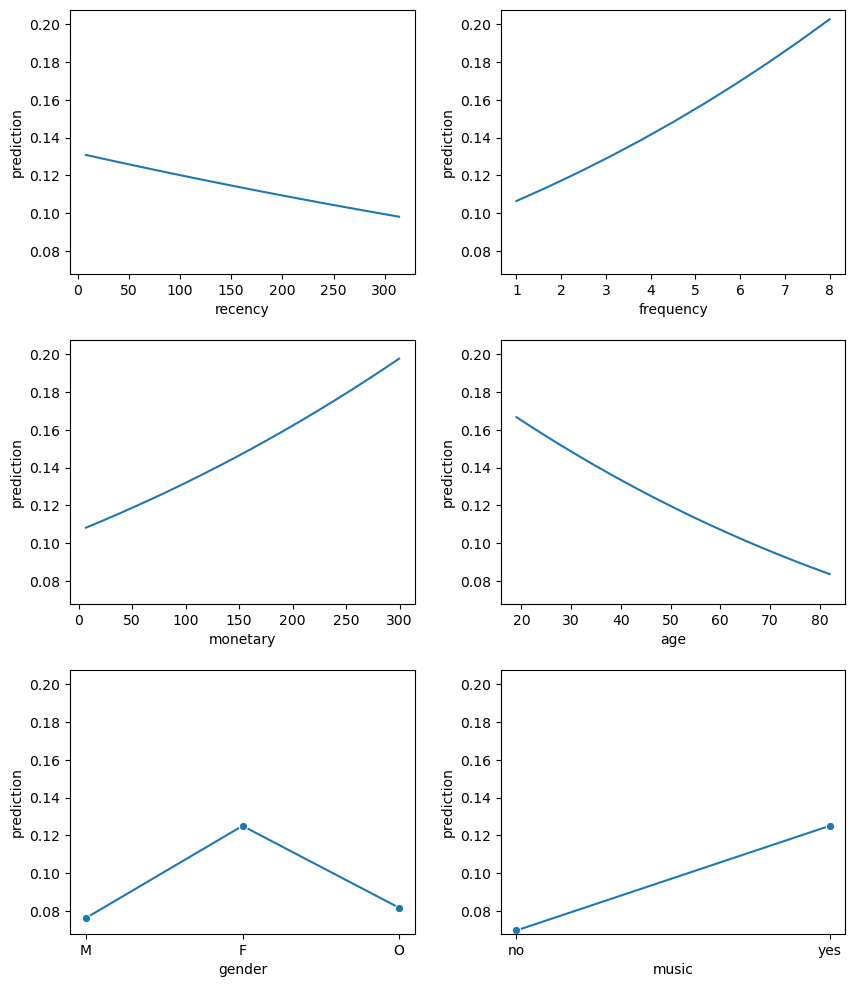

In [11]:
clf.plot("pred")



Based on the predictive plots:
- As recency increases, probability of purchase decreases, likely because you are not an active customer and are not enticed by more recent deals
- As frequency increases, probability of purchase increases, likely because you are a loyal customer and regularly respond to deals positively
- As monetary value increases, probability of purchase increases, likely because you are a high-value customer and are more likely to respond to deals 
- As age increases, probability of purchase decreases, likely because older members are not part of the customer base or the platforms where the deals are being offered
- Females tend to have a higher probability of purchase from deals
- Customers who made pruchases in the music category have a higher probability of purchase of the karaoke deal

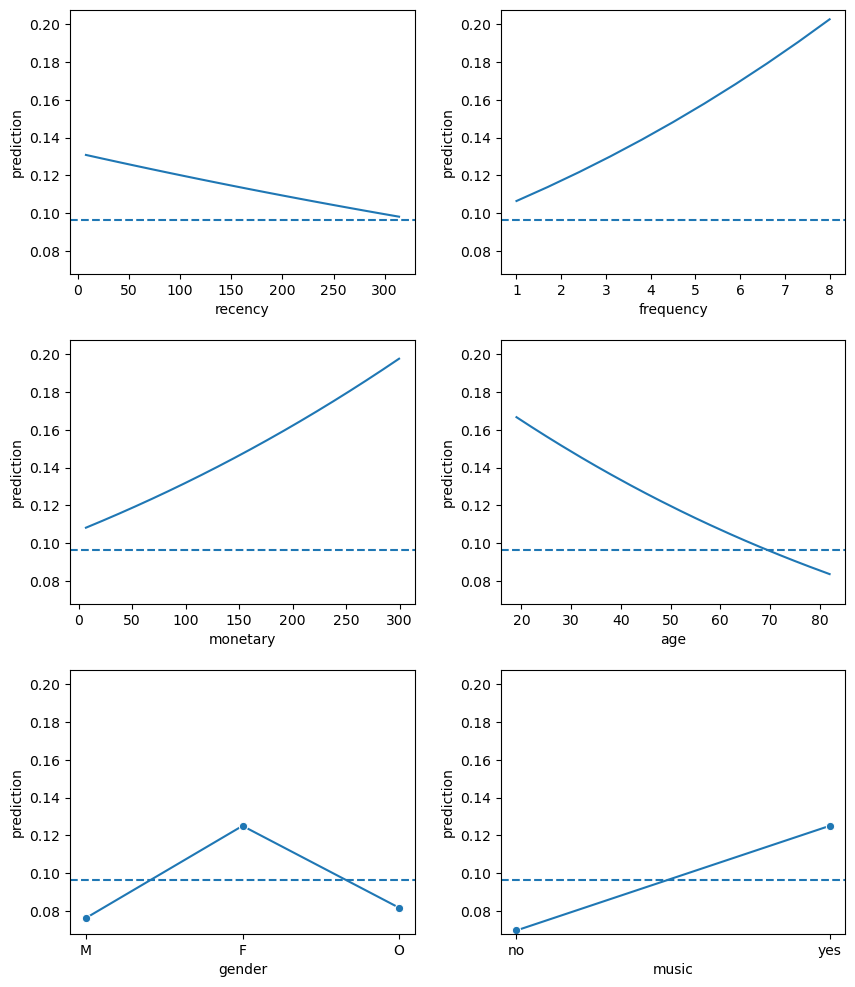

In [12]:
clf.plot("pred", hline=True)

Use Permutation Importance to assess variable importance. Which variables seem to be most and least important in the model? Explain how Permutation Importance allows you to evaluate variable importance.

{'recency': [0.004015289711944481], 'frequency': [0.02295255172753615], 'monetary': [0.024640762797690185], 'age': [0.025920032521041157], 'gender': [0.03395523927392737], 'music': [0.04080848650303402]}


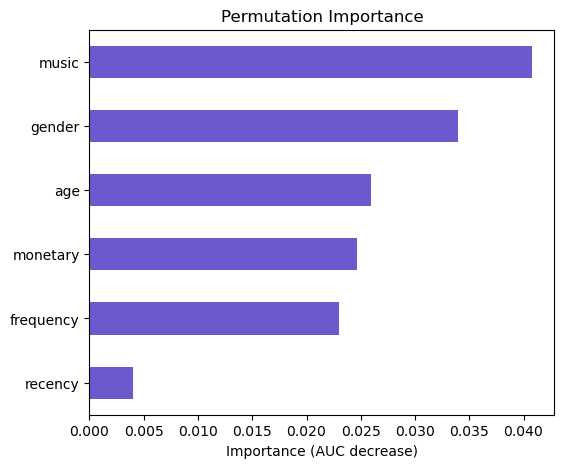

In [13]:
clf.plot("vimp")

Based on AUC decrease, classification performance (distinguish between true positive vs false positives) improves best with music and gender, with age, monetary, and frequency following. Recency is the least important variable in the model based on this permutation importance plot. 

Interest in music deals based on positive responses to previous music deals, gender, and age seem to capture customer profile and behavior patterns directly linked to the target variable, enabling the model to better distinguish potential buyers from non-buyers, and permuting these features significantly reduces the model's performance.


Add the predicted values from the logistic regression to the "tuango" DataFrame. Use "pred_logit" as the variable name. Compare the average of the predicted values to the overall response rate (i.e., proportion of buyers). 

In [14]:
tuango["pred_logit"] = clf.predict()["prediction"]
tuango.head()


,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1,0,0.141318
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1,0,0.064122
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1,0,0.072710
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1,0,0.088488
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1,0,0.080623


In [15]:
overall_response_rate = q1
predicted_mean = tuango["pred_logit"].mean()

print("Average of Predicted Values:", predicted_mean)
print("Overall Response Rate:", overall_response_rate)
print("Difference:", predicted_mean - overall_response_rate)
percent_difference = ((predicted_mean - overall_response_rate) / overall_response_rate) * 100
print("Percent Difference:", percent_difference, "%")



Average of Predicted Values: 0.09659991341853104
Overall Response Rate: 0.09661373636885402
Difference: -1.382295032298364e-05
Percent Difference: -0.014307437888759503 %


The overall response rae and the predicted values are very close, with the predicted values being slightly lower in value. However, it is important to note that the predicted values are based on the data used to estimate the model, which poses the risk of overfitting the training data and bias in evaluation and the model may not be able to generalize well to new data, and must be validated on a separate test set.

Estimate a linear regression model using "ordersize" as the response variable and recency, frequency, monetary, age, gender, and music as the explanatory variables. Estimate this regression using only those customers who placed an order after the deal offer message.

In [16]:
tuango_buyers = tuango[tuango["buyer_yes"] == 1]
tuango_buyers.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit
8,U79932394,yes,4.0,212,1.0,19.900000,59,F,yes,1.0,1,1,0.070039
14,U73924857,yes,5.0,177,10.0,40.000000,41,F,yes,1.0,1,1,0.213864
29,U74007327,yes,5.0,107,1.0,72.000000,26,O,yes,0.0,1,1,0.082310
34,U17047572,yes,3.0,101,4.0,70.000000,56,F,yes,0.0,1,1,0.120792
49,U67414450,yes,4.0,50,1.0,65.599998,20,F,yes,1.0,1,1,0.139709


In [17]:
clf2 = rsm.model.regress(
    data = {"tuango_buyers":tuango_buyers},
    rvar = "ordersize",
    evar = [
        "recency",
        "frequency",
        "monetary",
        "age",
        "gender",
        "music",
    ],
)
clf2.summary()

Linear regression (OLS)
Data                 : tuango_buyers
Response variable    : ordersize
Explanatory variables: recency, frequency, monetary, age, gender, music
Null hyp.: the effect of x on ordersize is zero
Alt. hyp.: the effect of x on ordersize is not zero

            coefficient  std.error  t.value p.value     
Intercept         3.665      0.174   21.104  < .001  ***
gender[F]         0.126      0.089    1.425   0.154     
gender[O]         0.259      0.208    1.243   0.214     
music[yes]        0.025      0.097    0.255   0.799     
recency           0.000      0.001    0.591   0.555     
frequency         0.023      0.016    1.456   0.145     
monetary          0.000      0.000    1.035   0.301     
age               0.001      0.003    0.389   0.697     

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.003, Adjusted R-squared: -0.0
F-statistic: 0.939 df(7, 2012), p.value 0.475
Nr obs: 2,020


Focusing on the group of buyers who have already made a purchase to understand the factors that influence the order size is a sensible approach as it allows the company to better identify the factors that drive the number of sessions purchased and tailor future marketing strategies to similar customers, while avoiding biases that might arise from including non-buyers. However, based on the regression results, none of the explaatory variables are significant (p value > 0.05 for all) it is not compelling to conclude that the null hypothesis can be rejected and the coefficients are not equal to zero. Additonally the low R-squared value (0.003), the model does not seem to capture the relationship between the explanatory variables and the response variable well, only explaining 0.3% of the variance in data, and ergo, may not be a good fit for the data. Lastly the overall model significance based on the F-statistic pvalue is also greater than 0.05 at 0.475, indicating that the model is not statistically significant. 

Use Permutation Importance to assess variable importance. 

{'recency': [0.0004343272825226884], 'frequency': [0.0012897696847334623], 'monetary': [0.0013339787778192148], 'age': [8.682003352560048e-05], 'gender': [0.0016886283858941777], 'music': [-7.960610958309377e-06]}


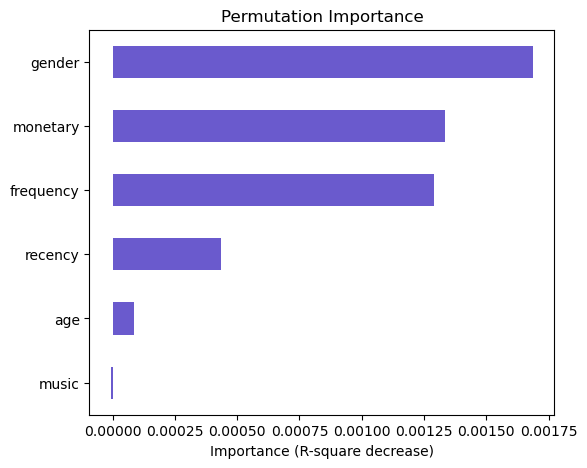

In [18]:
clf2.plot("vimp")

Gender, monetary, and frequency seem to be the most important variables in accurately predicting the order size, while age, music, and recency are the least important variables in the model.

The linear regression model suggests that none of the explanatory variables have a statistically significant effect on ordersize, as all the p values are > 0.05. The extremely low R-squared and negative adjusted R-squared imply that the model is not explaining the variation in ordersize. The low and insignificant F-statistic confirms that the explanatory variables collectively do not provide a better prediction than the baseline (intercept-only). 

Add the predicted values from the linear regression to the "tuango" data.frame. Compare the average of the predicted values to the average value of ordersize. Make sure to focus only on buyers. What do you notice?

In [19]:
tuango["pred_ordersize"] = clf2.predict()["prediction"]

In [20]:
tuango[tuango["buyer_yes"] == 1].head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit,pred_ordersize
8,U79932394,yes,4.0,212,1.0,19.900000,59,F,yes,1.0,1,1,0.070039,3.974319
14,U73924857,yes,5.0,177,10.0,40.000000,41,F,yes,1.0,1,1,0.213864,4.153051
29,U74007327,yes,5.0,107,1.0,72.000000,26,O,yes,0.0,1,1,0.082310,4.046473
34,U17047572,yes,3.0,101,4.0,70.000000,56,F,yes,0.0,1,1,0.120792,4.015176
49,U67414450,yes,4.0,50,1.0,65.599998,20,F,yes,1.0,1,1,0.139709,3.888904


In [21]:
predicted_ordersize_mean = tuango[tuango["buyer_yes"] == 1]["pred_ordersize"].mean()
actual_ordersize_mean = tuango[tuango["buyer_yes"] == 1]["ordersize"].mean()

print("Average of Predicted Order Size:", predicted_ordersize_mean)
print("Average of Actual Order Size:", actual_ordersize_mean)
print("Difference:", predicted_ordersize_mean - actual_ordersize_mean)
percent_difference_ordersize = ((predicted_ordersize_mean - actual_ordersize_mean) / actual_ordersize_mean) * 100
print("Percent Difference:", percent_difference_ordersize, "%")

Average of Predicted Order Size: 3.9410891089108957
Average of Actual Order Size: 3.9410891089108913
Difference: 4.440892098500626e-15
Percent Difference: 1.1268184950347023e-13 %


The means of the predicted values and the average order size actually noted have almost negligible difference, which suggests that the model works well on the trained dataset. There might be potential overfit, bias towards the training data, and the model may not generalize well to new data, and must be validated on a separate test set.

## Part III: Profitability Analysis


To calculate profit and return on marketing expenditures assume the following:
- Price per 30-minute session is 49 RMB
- Marginal cost of sending a deal offer message is 9 RMB
- Tuango’s fee on each deal sold is 50% of sales revenues




What is the breakeven response rate? 

In [22]:
nan_buyer_count = tuango["buyer"].isna().sum()
nan_buyer_count

397252

In [23]:
# state your assumptions that are relevant to calculate
# the breakeven response rate
# breakeven should be of type `float`

avg_ordersize_q2 = float(q2.loc["yes", "mean"].iloc[0])
cost = 9
margin = (49-(0.5*49)) * avg_ordersize_q2
breakeven =  cost / margin
q11 = breakeven # float, DO NOT APPLY ROUNDING, do not express as a percentage
q11


0.09320949834524941

What is the projected profit in RMB and the return on marketing expenditures if you offer the deal to all 397,252 remaining customers (i.e., target everyone)?

In [24]:
# insert calculation code here
# all variables should be numeric (integer or float) and of length 1
# _all stands for 'targeting all'
tuango["message_all"] = True

avg_ordersize_q2 = float(q2.loc["yes", "mean"].iloc[0])
overall_response_rate = float(q1)


nr_message_all =  tuango["buyer"].isna().sum() # total number of messages that would be sent out
message_cost_all = 9 * nr_message_all # total cost of sending messages to selected customers (float)
nr_responses_all = tuango["pred_logit"].mean() * nr_message_all # total number of positive responses
response_rate_all = tuango["pred_logit"].mean() # expressed as a proportion (no rounding)
revenue_all = 49 * avg_ordersize_q2 * nr_responses_all# total revenue in RMB (no rounding)
profit_all = 0.5 * revenue_all - message_cost_all # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_all = profit_all/message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)
ROME_all

0.036374137115548925

Evaluate the performance implications of offering the deal to only those customers (out of 397,252) with a predicted probability of purchase greater than the breakeven response rate. Determine the projected profit in RMB and the return on marketing expenditures for both approaches. 

Note: Fine tune the estimate from Q2 above by determining the average amount spent among the people that (1) will receive a message and (2) bought a karaoke deal. Also, use the actual number of messages you plan to send out to the group of customers in the rollout sample (i.e., “test == 0”)

In [25]:
tuango["message_logit"] = (tuango["pred_logit"] > q11) & (tuango["buyer"].isna())
tuango.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit,pred_ordersize,message_all,message_logit
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1,0,0.141318,NaN,True,False
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1,0,0.064122,NaN,True,False
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1,0,0.072710,NaN,True,False
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1,0,0.088488,NaN,True,False
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1,0,0.080623,NaN,True,False


In [26]:
breakeven_tuango = tuango[tuango["message_logit"] == True]
breakeven_tuango.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,buyer_yes,pred_logit,pred_ordersize,message_all,message_logit
20910,U59772099,NaN,NaN,185,8.0,123.599998,46,O,yes,NaN,0,NaN,0.134632,NaN,True,True
20912,U36020329,NaN,NaN,31,8.0,95.000000,33,F,yes,NaN,0,NaN,0.244048,NaN,True,True
20914,U41061867,NaN,NaN,97,9.0,7.830000,46,F,no,NaN,0,NaN,0.107997,NaN,True,True
20915,U45367432,NaN,NaN,77,9.0,65.000000,52,F,no,NaN,0,NaN,0.116449,NaN,True,True
20919,U72456768,NaN,NaN,12,2.0,120.000000,78,F,yes,NaN,0,NaN,0.094480,NaN,True,True


In [27]:
nr_message_logit = tuango["message_logit"].sum() # total number of messages that would be sent out
message_cost_logit = 9 * nr_message_logit # total cost of sending messages to selected customers (float)
nr_responses_logit =  breakeven_tuango["pred_logit"].mean() * nr_message_logit # total number of positive responses
response_rate_logit = breakeven_tuango["pred_logit"].mean() # expressed as a proportion (no rounding)
revenue_logit = 49 * avg_ordersize_q2 * nr_responses_logit # total revenue in RMB (no rounding)
profit_logit =  0.5 * revenue_logit - message_cost_logit# 0.5 * revenue - message_cost - total profit in RMB (no rounding)
ROME_logit = profit_logit/message_cost_logit # Return on Marketing Expenditures expressed as a proportion (no rounding)
ROME_logit

0.5059460579340642

Create a bar chart with profit information for the analyses 

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt


In [29]:
performance_data = pd.DataFrame(
    {
        "name": ["No targeting", "Logistic"],
        "Profit": [profit_all, profit_logit],
        "ROME": [ROME_all, ROME_logit],
    }
)

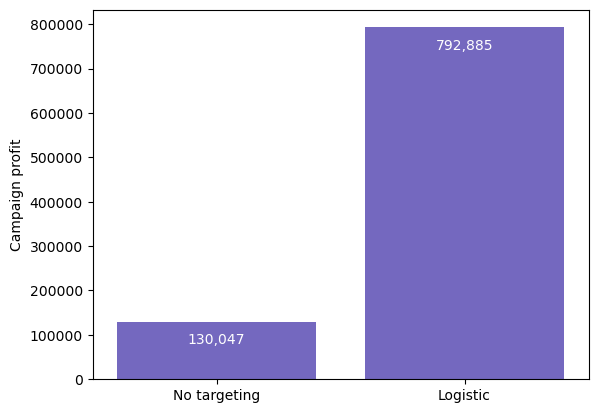

In [30]:
plt.clf()
fig = sns.barplot(x="name", y="Profit", color="slateblue", data=performance_data)
fig.set(xlabel="", ylabel="Campaign profit")
for index, row in performance_data.iterrows():
    fig.text(row.name, row.Profit - 50000, f"{int(row.Profit):,}", color="white", ha="center")
plt.show()


Create a bar chart with ROME for the analyses

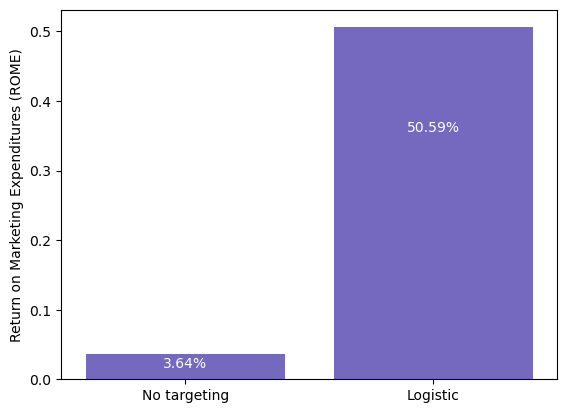

In [31]:
plt.clf()
fig = sns.barplot(x="name", y="ROME", color="slateblue", data=performance_data)
fig.set(xlabel="", ylabel="Return on Marketing Expenditures (ROME)")
for index, row in performance_data.iterrows():
    adj = rsm.ifelse(index == 0, 0.02, 0.15)
    fig.text(
        row.name,
        row.ROME - adj,
        f"{round((100*row.ROME), 2):,}%",
        color="white",
        ha="center",
    )
plt.show()


Utilizing the post-dataset:Tuango decided to contact all remaining 397,252 customers because this would provide data that could be used to evaluate different targeting approaches. The data has a "test" variable (test = 1 for the data used in the test, test = 0 for the remaining customers). Use this variable to evaluate the actual performance on the 'roll out' (test == 0) sample for the targeting approaches 


In [32]:
tuango_post = pd.read_parquet("data/tuango_post.parquet")
tuango_post.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1


In [33]:
tuango_post_test = tuango_post[tuango_post["test"] == 1]
tuango_post_test.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test
0,U15889344,no,0.0,309,7.0,39.799999,44,F,yes,0.0,1
1,U60246497,no,0.0,297,8.0,39.799999,80,M,yes,1.0,1
2,U22965759,no,0.0,295,1.0,72.900002,59,F,yes,1.0,1
3,U40811142,no,0.0,277,1.0,40.000000,37,F,yes,0.0,1
4,U76283952,no,0.0,259,1.0,21.000000,43,F,yes,1.0,1


In [34]:
tuango_post_rollout = tuango_post[tuango_post["test"] == 0]
tuango_post_rollout.head()

,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test
20908,U78589602,no,0.0,8,1.0,115.330000,71,F,yes,NaN,0
20909,U83705520,no,0.0,274,1.0,58.000000,46,F,yes,NaN,0
20910,U59772099,no,0.0,185,8.0,123.599998,46,O,yes,NaN,0
20911,U22464840,no,0.0,127,3.0,87.810000,46,M,no,NaN,0
20912,U36020329,no,0.0,31,8.0,95.000000,33,F,yes,NaN,0


In [35]:
tuango_post_rollout["pred_logit"] = clf.predict(tuango_post_rollout)["prediction"]
tuango_post_rollout.head()

/tmp/ipykernel_249546/1202059217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuango_post_rollout["pred_logit"] = clf.predict(tuango_post_rollout)["prediction"]


,userid,buyer,ordersize,recency,frequency,monetary,age,gender,music,training,test,pred_logit
20908,U78589602,no,0.0,8,1.0,115.330000,71,F,yes,NaN,0,0.092104
20909,U83705520,no,0.0,274,1.0,58.000000,46,F,yes,NaN,0,0.083355
20910,U59772099,no,0.0,185,8.0,123.599998,46,O,yes,NaN,0,0.134632
20911,U22464840,no,0.0,127,3.0,87.810000,46,M,no,NaN,0,0.041179
20912,U36020329,no,0.0,31,8.0,95.000000,33,F,yes,NaN,0,0.244048


In [36]:
count_tuango_post = tuango_post.shape[0]
count_tuango_post_test = tuango_post_test.shape[0]
count_tuango_post_rollout = tuango_post_rollout.shape[0]

print("Count of rows in tuango_post:", count_tuango_post)
print("Count of rows in tuango_post_test:", count_tuango_post_test)
print("Count of rows in tuango_post_rollout:", count_tuango_post_rollout)

Count of rows in tuango_post: 418160
Count of rows in tuango_post_test: 20908
Count of rows in tuango_post_rollout: 397252


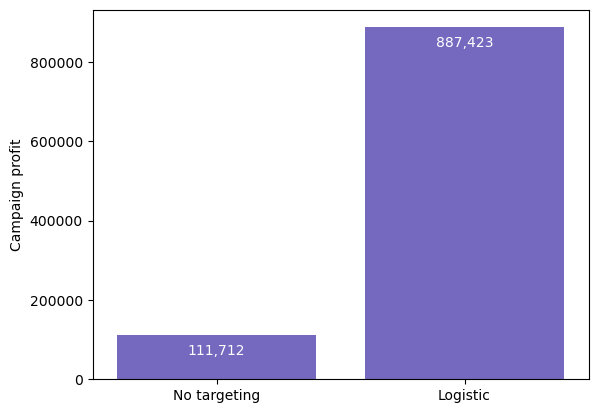

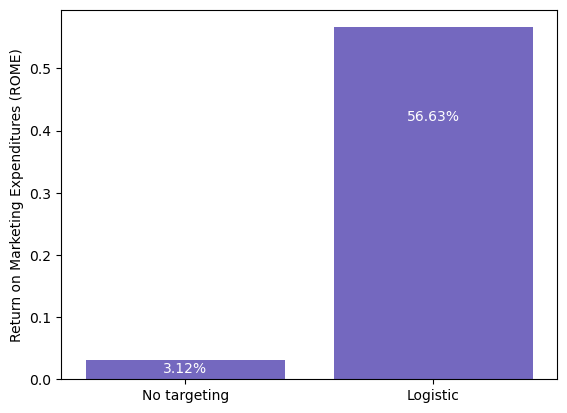

In [37]:

#q12 - actual 'no target'
actual_nr_responses_all = tuango_post_rollout["buyer"].value_counts().get("yes", 0)
message_cost_all = 9 * count_tuango_post_rollout
avg_ordersize_all = tuango_post_rollout[tuango_post_rollout["buyer"] == "yes"]["ordersize"].mean()
actual_revenue_all = 49 * avg_ordersize_all * actual_nr_responses_all
actual_profit_all = 0.5 * actual_revenue_all - message_cost_all
actual_ROME_all = actual_profit_all / message_cost_all

#q13 - actual 'logistic'
logit_rollout_sample = tuango_post_rollout[tuango_post_rollout["pred_logit"] > q11]
actual_nr_responses_logit = logit_rollout_sample["buyer"].value_counts().get("yes", 0)
message_cost_logit = 9 * logit_rollout_sample.shape[0]
avg_ordersize_logit = logit_rollout_sample[logit_rollout_sample["buyer"] == "yes"]["ordersize"].mean()
actual_revenue_logit = 49 * avg_ordersize_logit * actual_nr_responses_logit
actual_profit_logit = 0.5 * actual_revenue_logit - message_cost_logit
actual_ROME_logit = actual_profit_logit / message_cost_logit

# Create a DataFrame with the actual performance data
actual_performance_data = pd.DataFrame(
    {
        "name": ["No targeting", "Logistic"],
        "Profit": [actual_profit_all, actual_profit_logit],
        "ROME": [actual_ROME_all, actual_ROME_logit],
    }
)

# Re-create the bar chart for profit
plt.clf()
fig = sns.barplot(x="name", y="Profit", color="slateblue", data=actual_performance_data)
fig.set(xlabel="", ylabel="Campaign profit")
for index, row in actual_performance_data.iterrows():
    fig.text(row.name, row.Profit - 50000, f"{int(row.Profit):,}", color="white", ha="center")
plt.show()

# Re-create the bar chart for ROME
plt.clf()
fig = sns.barplot(x="name", y="ROME", color="slateblue", data=actual_performance_data)
fig.set(xlabel="", ylabel="Return on Marketing Expenditures (ROME)")
for index, row in actual_performance_data.iterrows():
    adj = 0.15 if index == 1 else 0.02
    fig.text(
        row.name,
        row.ROME - adj,
        f"{round((100*row.ROME), 2):,}%",
        color="white",
        ha="center",
    )
plt.show()